# 01 — EDA: synthetic live-event viewership panel

Reads `data/generated/events.parquet` — the fully synthetic dataset described in `docs/DESIGN.md`. Every figure here is written to `docs/figs/` (not just rendered inline); `scripts/check_eda.py` re-executes this notebook headlessly and checks the figures and the printed baseline share exist and land in the target band.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from mmm_sports.simulate.schedule import CALENDAR_START, TENTPOLE_TIERS
from mmm_sports.simulate.spend import generate_alwayson_spend
from mmm_sports.simulate.truth import ALWAYS_ON, EVENT_TARGETED


def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (no pyproject.toml found)")


REPO_ROOT = _find_repo_root(Path.cwd())
DATA_PATH = REPO_ROOT / "data" / "generated" / "events.parquet"
FIGS_DIR = REPO_ROOT / "docs" / "figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0  # matches the seed events.parquet was generated with (scripts/simulate_data.py)

# dataviz skill palette -- fixed categorical order, never cycled.
COLOR_BLUE = "#2a78d6"
COLOR_ORANGE = "#eb6834"
COLOR_AQUA = "#1baf7a"
COLOR_YELLOW = "#eda100"
ORDINAL_BLUE_RAMP = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]  # steps 250/400/550/700, for tentpole_tier

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"

plt.rcParams.update(
    {
        "axes.edgecolor": GRIDLINE,
        "axes.labelcolor": INK_SECONDARY,
        "text.color": INK_PRIMARY,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "grid.color": GRIDLINE,
        "font.family": "sans-serif",
    }
)

df = pd.read_parquet(DATA_PATH)

print("=== Dataset summary ===")
print(f"Rows (events): {len(df)}")
print(f"Seasons: {df['season'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Columns: {len(df.columns)}")

=== Dataset summary ===
Rows (events): 739
Seasons: 3
Date range: 2021-09-01 to 2023-10-15
Columns: 28


## Viewership distribution

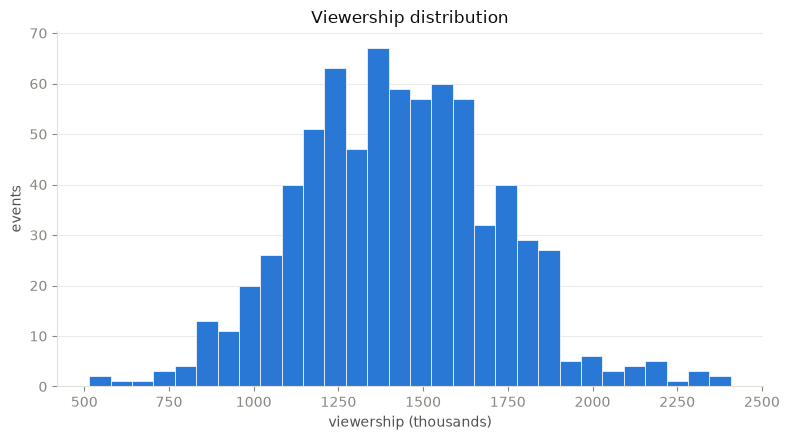

=== Viewership summary (thousands) ===
count     739.0
mean     1426.7
std       292.3
min       514.6
25%      1225.1
50%      1423.8
75%      1613.4
max      2407.7


In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["viewership"], bins=30, color=COLOR_BLUE, edgecolor="white", linewidth=0.5)
ax.set_xlabel("viewership (thousands)")
ax.set_ylabel("events")
ax.set_title("Viewership distribution")
ax.grid(axis="y", linewidth=0.75, alpha=0.6)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIGS_DIR / "eda_viewership_distribution.png", dpi=120)
plt.show()

print("=== Viewership summary (thousands) ===")
print(df["viewership"].describe().round(1).to_string())

## Always-on spend over calendar time

Regenerated from the same seed (`generate_alwayson_spend`) rather than read from the event-level parquet — always-on spend lives on the daily calendar, and events only sample a fraction of days, so this is the only view that shows the actual flighting (bursts, dark periods, seasonal ramp) from `DESIGN.md §4`.

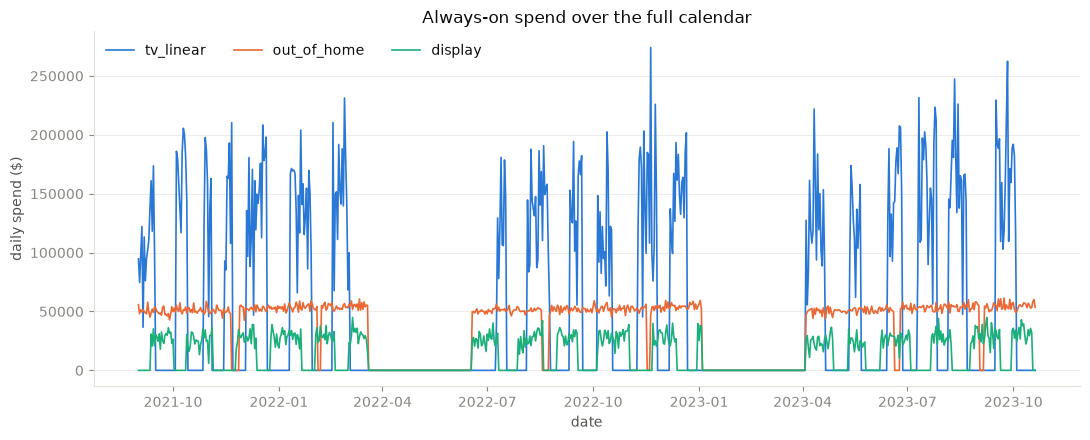

In [3]:
alwayson = generate_alwayson_spend(seed=SEED)
alwayson_dates = CALENDAR_START + pd.to_timedelta(alwayson["day_idx"], unit="D")

fig, ax = plt.subplots(figsize=(11, 4.5))
channel_colors = {"tv_linear": COLOR_BLUE, "out_of_home": COLOR_ORANGE, "display": COLOR_AQUA}
for channel, color in channel_colors.items():
    ax.plot(alwayson_dates, alwayson[channel], color=color, linewidth=1.2, label=channel)
ax.set_xlabel("date")
ax.set_ylabel("daily spend ($)")
ax.set_title("Always-on spend over the full calendar")
ax.legend(frameon=False, ncols=3, loc="upper left")
ax.grid(axis="y", linewidth=0.75, alpha=0.6)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIGS_DIR / "eda_spend_alwayson.png", dpi=120)
plt.show()

## Event-targeted spend over time

Already event-level (no adstock, no daily calendar). Color shows the tentpole-tier concentration that's the project's central confound (`DESIGN.md §3`) — higher tiers should visibly sit higher.

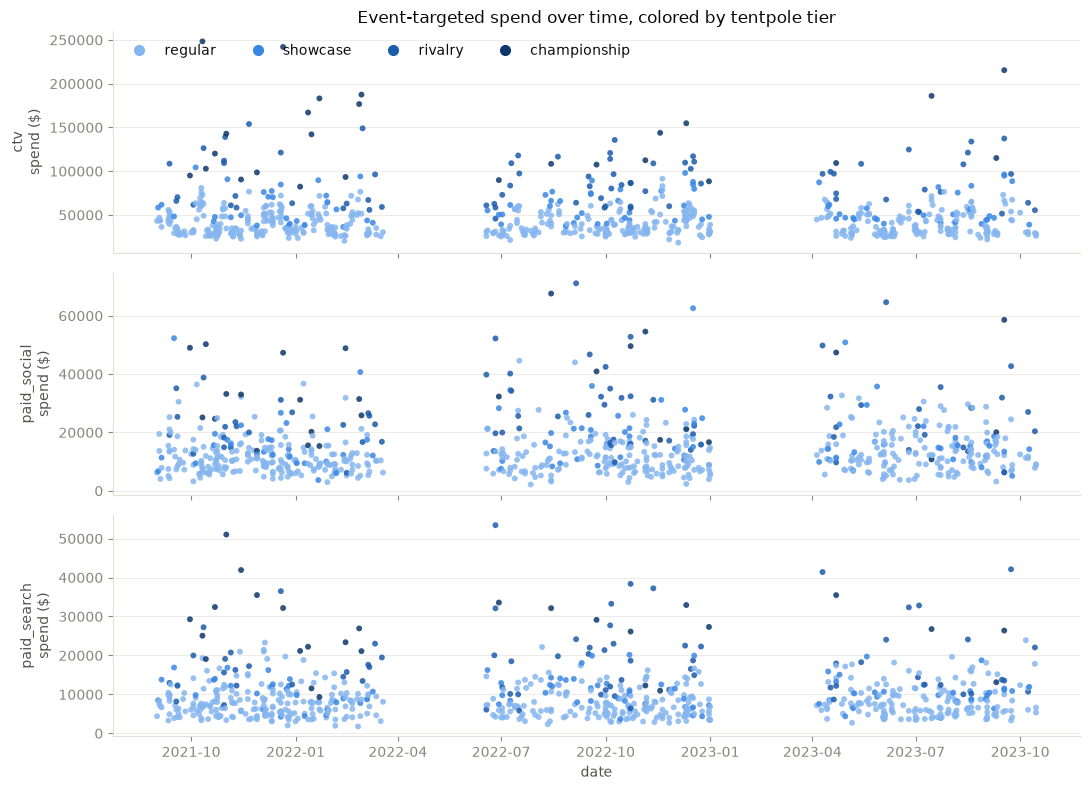

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
tier_rank = df["tentpole_tier"].cat.codes
tier_colors = [ORDINAL_BLUE_RAMP[r] for r in tier_rank]
for ax, channel in zip(axes, EVENT_TARGETED):
    ax.scatter(df["date"], df[f"spend_{channel}"], c=tier_colors, s=18, alpha=0.85, edgecolor="none")
    ax.set_ylabel(f"{channel}\nspend ($)")
    ax.grid(axis="y", linewidth=0.75, alpha=0.6)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
axes[-1].set_xlabel("date")
axes[0].set_title("Event-targeted spend over time, colored by tentpole tier")

# Manual legend: color here encodes an ordered category, not a plain scatter series.
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=c, markersize=7) for c in ORDINAL_BLUE_RAMP
]
axes[0].legend(handles, TENTPOLE_TIERS, frameon=False, ncols=4, loc="upper left")

fig.tight_layout()
fig.savefig(FIGS_DIR / "eda_spend_eventtargeted.png", dpi=120)
plt.show()

## Baseline dominance

Mean contribution share of the noise-free response `mu`, by bucket — the number every later model's decomposition (Phase 3 SHAP, Phase 5 posterior) gets compared against. Target bands from `DESIGN.md §4`.

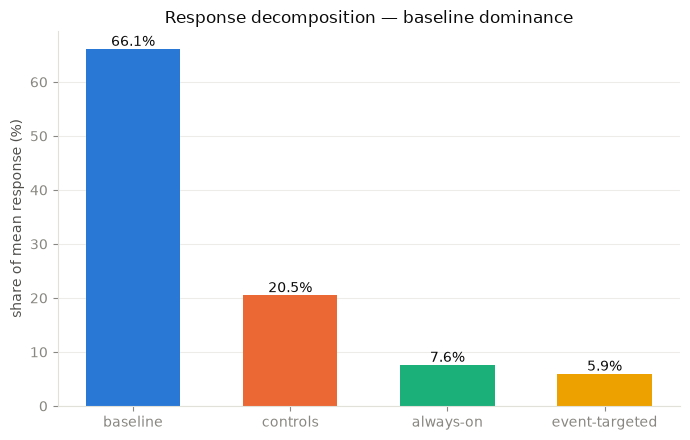

Baseline share: 66.1%


In [5]:
mu_mean = df["mu"].mean()
shares = {
    "baseline": df["contrib_baseline"].mean() / mu_mean,
    "controls": df["contrib_controls"].mean() / mu_mean,
    "always-on": sum(df[f"contrib_{ch}"].mean() for ch in ALWAYS_ON) / mu_mean,
    "event-targeted": sum(df[f"contrib_{ch}"].mean() for ch in EVENT_TARGETED) / mu_mean,
}

fig, ax = plt.subplots(figsize=(7, 4.5))
bucket_colors = [COLOR_BLUE, COLOR_ORANGE, COLOR_AQUA, COLOR_YELLOW]
bars = ax.bar(list(shares.keys()), [v * 100 for v in shares.values()], color=bucket_colors, width=0.6)
ax.set_ylabel("share of mean response (%)")
ax.set_title("Response decomposition — baseline dominance")
ax.grid(axis="y", linewidth=0.75, alpha=0.6)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for bar, value in zip(bars, shares.values()):
    ax.annotate(
        f"{value:.1%}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        color=INK_PRIMARY,
        fontsize=10,
    )
fig.tight_layout()
fig.savefig(FIGS_DIR / "eda_baseline_dominance.png", dpi=120)
plt.show()

print(f"Baseline share: {shares['baseline']:.1%}")

## Diagnostics

Printed checks, not data treatment — this is synthetic ground truth, and the high-viewership tentpole events below are deliberate signal, not outliers to clip (see `docs/DECISIONS.md`, task 2.1). These foreshadow the 5.5c collinearity check and the tentpole confounder without duplicating either.

In [6]:
spend_cols = [f"spend_{ch}" for ch in (*ALWAYS_ON, *EVENT_TARGETED)]
print("=== Media spend collinearity preview ===")
print(df[spend_cols].corr().round(2).to_string())

=== Media spend collinearity preview ===
                   spend_tv_linear  spend_out_of_home  spend_display  spend_ctv  spend_paid_social  spend_paid_search
spend_tv_linear               1.00               0.03          -0.20       0.54              -0.03               0.01
spend_out_of_home             0.03               1.00           0.00       0.01               0.03               0.03
spend_display                -0.20               0.00           1.00      -0.14              -0.03              -0.00
spend_ctv                     0.54               0.01          -0.14       1.00               0.40               0.50
spend_paid_social            -0.03               0.03          -0.03       0.40               1.00               0.42
spend_paid_search             0.01               0.03          -0.00       0.50               0.42               1.00


In [7]:
print("=== Zero-spend / flighting inflation (always-on daily calendar) ===")
for channel in ALWAYS_ON:
    zero_frac = (alwayson[channel] == 0).mean()
    print(f"  {channel}: {zero_frac:.1%} of calendar days at zero spend")

print("\nEvent-targeted channels are never zero by construction (every event gets")
print("some spend; DESIGN.md section 4 -- no dark periods, no adstock).")

=== Zero-spend / flighting inflation (always-on daily calendar) ===
  tv_linear: 65.8% of calendar days at zero spend
  out_of_home: 26.7% of calendar days at zero spend
  display: 53.2% of calendar days at zero spend

Event-targeted channels are never zero by construction (every event gets
some spend; DESIGN.md section 4 -- no dark periods, no adstock).


In [8]:
print("=== Tentpole-tier leverage on viewership ===")
tier_summary = df.groupby("tentpole_tier", observed=True).agg(
    n_events=("event_id", "count"),
    mean_viewership=("viewership", "mean"),
).reindex(TENTPOLE_TIERS)
tier_summary["share_of_total_viewership"] = (
    df.groupby("tentpole_tier", observed=True)["viewership"].sum().reindex(TENTPOLE_TIERS)
    / df["viewership"].sum()
)
print(tier_summary.round({"mean_viewership": 0, "share_of_total_viewership": 3}).to_string())

=== Tentpole-tier leverage on viewership ===
               n_events  mean_viewership  share_of_total_viewership
tentpole_tier                                                      
regular             547           1354.0                      0.702
showcase             91           1520.0                      0.131
rivalry              74           1685.0                      0.118
championship         27           1885.0                      0.048
